# 🔍 Detecção de Anomalias em Transações Financeiras

**Projeto do Bootcamp DIO — Detecção de Fraudes com Machine Learning**

Este notebook implementa um pipeline completo de detecção de anomalias (fraudes) em transações de cartão de crédito, utilizando o algoritmo **Isolation Forest**.

**Dataset:** [Credit Card Fraud Detection (Kaggle)](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Fluxo do projeto:**
1. Exploração e Limpeza de Dados (EDA)
2. Engenharia de Recursos (Feature Engineering)
3. Treinamento do Modelo (Isolation Forest)
4. Avaliação dos Resultados (Recall, Precision, Matriz de Confusão)

## 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Exploração e Limpeza de Dados (EDA)

Carregamos o dataset `creditcard.csv` (baixe em [kaggle.com/datasets/mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) e coloque na pasta `data/`).

O dataset contém:
- `Time`: segundos desde a primeira transação registrada
- `V1` a `V28`: variáveis numéricas anonimizadas (resultado de uma transformação PCA, por confidencialidade)
- `Amount`: valor da transação
- `Class`: variável-alvo (`0` = transação normal, `1` = fraude)

In [2]:
df = pd.read_csv("data/creditcard.csv")

print(f"Formato do dataset: {df.shape[0]} linhas, {df.shape[1]} colunas")
df.head()

Formato do dataset: 284807 linhas, 31 colunas


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Informações gerais e tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
# Verificação de valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum().sum(), "valores nulos no total")

Valores nulos por coluna:
0 valores nulos no total


In [5]:
# Estatísticas descritivas
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 2.1 O Grande Desafio: Dados Desbalanceados

Vamos verificar a proporção entre transações normais e fraudulentas.

In [6]:
contagem_classes = df["Class"].value_counts()
percentual_classes = df["Class"].value_counts(normalize=True) * 100

print("Contagem de transações por classe:")
print(contagem_classes)
print()
print("Percentual:")
print(percentual_classes.round(4))

Contagem de transações por classe:
Class
0    284315
1       492
Name: count, dtype: int64

Percentual:
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


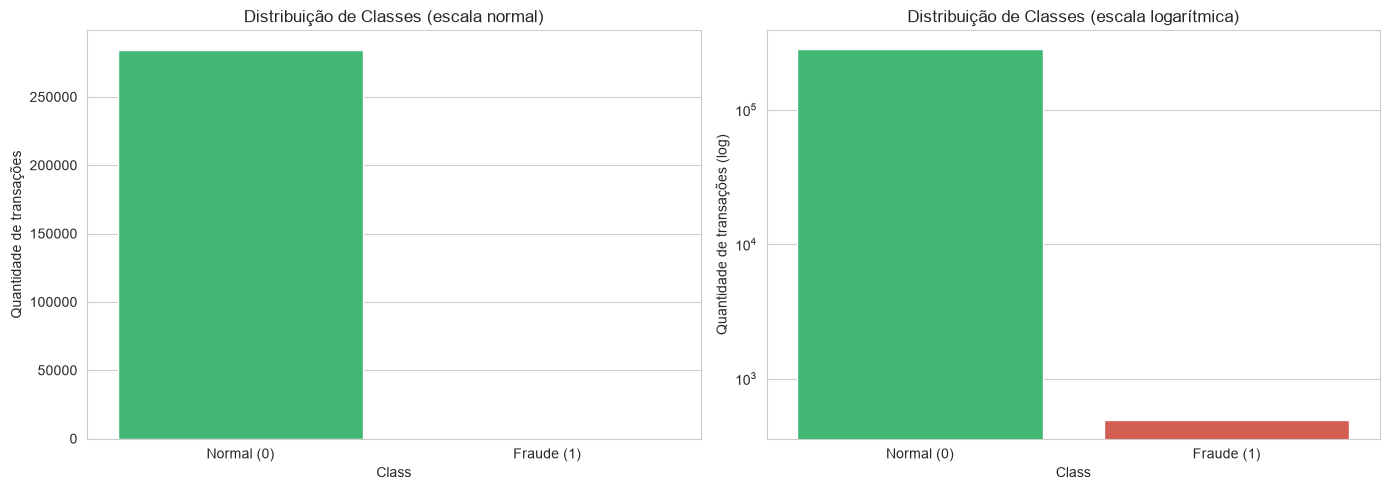

⚠️  As fraudes representam apenas 0.173% do total de transações.
Por isso, NÃO podemos usar acurácia simples como métrica de sucesso.


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x="Class", data=df, hue="Class", ax=ax[0], palette=["#2ecc71", "#e74c3c"], legend=False)
ax[0].set_title("Distribuição de Classes (escala normal)")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Normal (0)", "Fraude (1)"])
ax[0].set_ylabel("Quantidade de transações")

sns.countplot(x="Class", data=df, hue="Class", ax=ax[1], palette=["#2ecc71", "#e74c3c"], legend=False)
ax[1].set_yscale("log")
ax[1].set_title("Distribuição de Classes (escala logarítmica)")
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["Normal (0)", "Fraude (1)"])
ax[1].set_ylabel("Quantidade de transações (log)")

plt.tight_layout()
plt.savefig("images/distribuicao_classes.png", dpi=120)
plt.show()

print(f"⚠️  As fraudes representam apenas {percentual_classes[1]:.3f}% do total de transações.")
print("Por isso, NÃO podemos usar acurácia simples como métrica de sucesso.")

### 2.2 Análise do Valor (`Amount`) por Classe

Vamos comparar a distribuição dos valores de transação entre transações normais e fraudulentas.

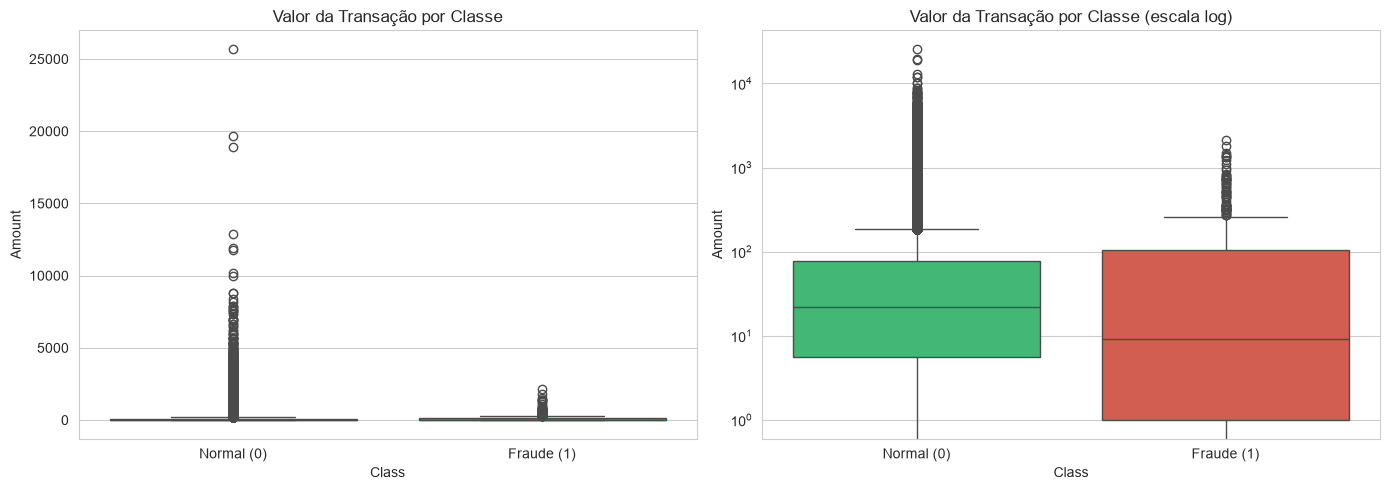

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x="Class", y="Amount", data=df, hue="Class", ax=ax[0], palette=["#2ecc71", "#e74c3c"], legend=False)
ax[0].set_title("Valor da Transação por Classe")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["Normal (0)", "Fraude (1)"])

sns.boxplot(x="Class", y="Amount", data=df, hue="Class", ax=ax[1], palette=["#2ecc71", "#e74c3c"], legend=False)
ax[1].set_yscale("log")
ax[1].set_title("Valor da Transação por Classe (escala log)")
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels(["Normal (0)", "Fraude (1)"])

plt.tight_layout()
plt.savefig("images/amount_por_classe.png", dpi=120)
plt.show()

In [9]:
print("Estatísticas do valor (Amount) — Transações NORMAIS:")
print(df[df["Class"] == 0]["Amount"].describe())
print()
print("Estatísticas do valor (Amount) — Transações FRAUDULENTAS:")
print(df[df["Class"] == 1]["Amount"].describe())

Estatísticas do valor (Amount) — Transações NORMAIS:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Estatísticas do valor (Amount) — Transações FRAUDULENTAS:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


## 3. Engenharia de Recursos (Feature Engineering)

As variáveis `V1` a `V28` já estão padronizadas (resultado de PCA). Porém, a coluna `Amount` tem escala muito diferente — e a coluna `Time` não traz informação direta de padrão, apenas o instante da transação.

Vamos:
1. Padronizar `Amount` com `StandardScaler`
2. Remover (ou transformar) a coluna `Time`, pois ela representa apenas o timestamp relativo e não ajuda o modelo de detecção de outliers

In [10]:
scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

# Comparação antes/depois
print("Amount original (primeiras linhas):")
print(df["Amount"].head())
print()
print("Amount padronizado (primeiras linhas):")
print(df["Amount_scaled"].head())

Amount original (primeiras linhas):
0    149.62
1      2.69
2    378.66
3    123.50
4     69.99
Name: Amount, dtype: float64

Amount padronizado (primeiras linhas):
0    0.244964
1   -0.342475
2    1.160686
3    0.140534
4   -0.073403
Name: Amount_scaled, dtype: float64


In [11]:
# Monta o dataset final de features (X) e target (y)
# Removemos 'Time' (não relevante para o padrão de outlier) e 'Amount' original (já padronizado)
colunas_features = [col for col in df.columns if col.startswith("V")] + ["Amount_scaled"]

X = df[colunas_features]
y = df["Class"]

print(f"Features utilizadas ({len(colunas_features)}): {colunas_features}")
print(f"Formato de X: {X.shape}")
print(f"Formato de y: {y.shape}")

Features utilizadas (29): ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled']
Formato de X: (284807, 29)
Formato de y: (284807,)


## 4. Treinamento do Modelo — Isolation Forest

O **Isolation Forest** é um algoritmo não supervisionado de detecção de anomalias. Diferente de modelos de classificação tradicionais, ele não aprende "o que é fraude" — ele aprende **o padrão do normal** e isola os pontos que se desviam muito desse padrão.

**Como funciona:**
- Constrói várias árvores de decisão aleatórias
- Anomalias são isoladas mais rapidamente (com menos divisões) do que pontos normais, pois são "diferentes" da maioria
- Cada ponto recebe um *anomaly score*: quanto mais próximo de `-1`, mais anômalo

**Parâmetro-chave:** `contamination` — a proporção esperada de outliers no dataset. Vamos usar a proporção real de fraudes que calculamos na EDA.

In [12]:
# Proporção real de fraudes no dataset (calculada na EDA)
proporcao_fraude = y.mean()
print(f"Proporção de fraudes (contamination): {proporcao_fraude:.5f}")

modelo = IsolationForest(
    n_estimators=100,       # número de árvores
    contamination=proporcao_fraude,  # proporção esperada de anomalias
    random_state=42,
    n_jobs=-1
)

modelo.fit(X)

print("Modelo treinado com sucesso!")

Proporção de fraudes (contamination): 0.00173
Modelo treinado com sucesso!


In [13]:
# Predição: o Isolation Forest retorna 1 para normal e -1 para anomalia
y_pred_raw = modelo.predict(X)

# Convertendo para o mesmo padrão do dataset: 0 = normal, 1 = fraude
y_pred = np.where(y_pred_raw == -1, 1, 0)

# Scores de anomalia (quanto menor/mais negativo, mais anômalo)
scores_anomalia = modelo.decision_function(X)

df["anomaly_score"] = scores_anomalia
df["predicao"] = y_pred

print("Predições geradas.")
print(f"Total de transações classificadas como fraude pelo modelo: {y_pred.sum()}")

Predições geradas.
Total de transações classificadas como fraude pelo modelo: 492


## 5. Avaliação dos Resultados

⚠️ **Atenção:** Não usamos acurácia tradicional aqui, pois com 99.8% de transações normais, um modelo "burro" que sempre prevê "normal" teria ~99.8% de acurácia e ZERO utilidade prática.

As métricas que realmente importam:

- **Recall (Sensibilidade):** de todas as fraudes reais, quantas o modelo conseguiu identificar? *(queremos isso o mais próximo de 100% possível)*
- **Precision (Precisão):** das transações marcadas como fraude, quantas realmente eram? *(queremos evitar bloquear clientes legítimos por engano)*
- **F1-score:** equilíbrio entre as duas métricas anteriores

In [14]:
print("=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("=" * 60)
print(classification_report(y, y_pred, target_names=["Normal", "Fraude"]))

RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
      Fraude       0.28      0.28      0.28       492

    accuracy                           1.00    284807
   macro avg       0.64      0.64      0.64    284807
weighted avg       1.00      1.00      1.00    284807



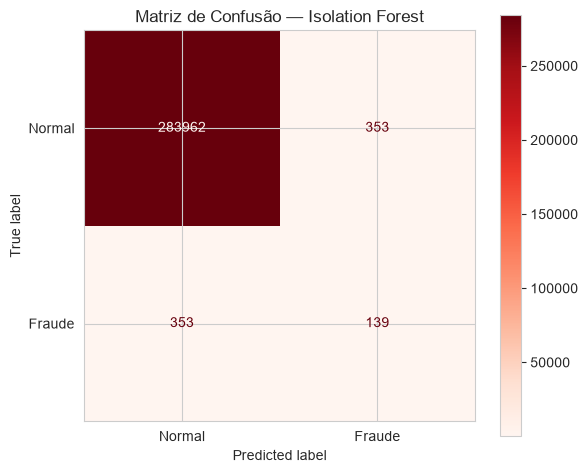


Verdadeiros Negativos (normal, previsto normal):  283962
Falsos Positivos (normal, previsto fraude):       353
Falsos Negativos (fraude, previsto normal):       353  ⚠️ fraudes que passaram batido
Verdadeiros Positivos (fraude, previsto fraude):  139  ✅ fraudes detectadas


In [15]:
matriz_confusao = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=["Normal", "Fraude"])
disp.plot(ax=ax, cmap="Reds", values_format="d")
ax.set_title("Matriz de Confusão — Isolation Forest")
plt.tight_layout()
plt.savefig("images/matriz_confusao.png", dpi=120)
plt.show()

tn, fp, fn, tp = matriz_confusao.ravel()
print(f"\nVerdadeiros Negativos (normal, previsto normal):  {tn}")
print(f"Falsos Positivos (normal, previsto fraude):       {fp}")
print(f"Falsos Negativos (fraude, previsto normal):       {fn}  ⚠️ fraudes que passaram batido")
print(f"Verdadeiros Positivos (fraude, previsto fraude):  {tp}  ✅ fraudes detectadas")

### 5.1 Visualização das Anomalias Detectadas

Vamos plotar as transações no espaço de duas das variáveis mais relevantes (`V1` e `V2`), destacando em vermelho as anomalias detectadas pelo modelo.

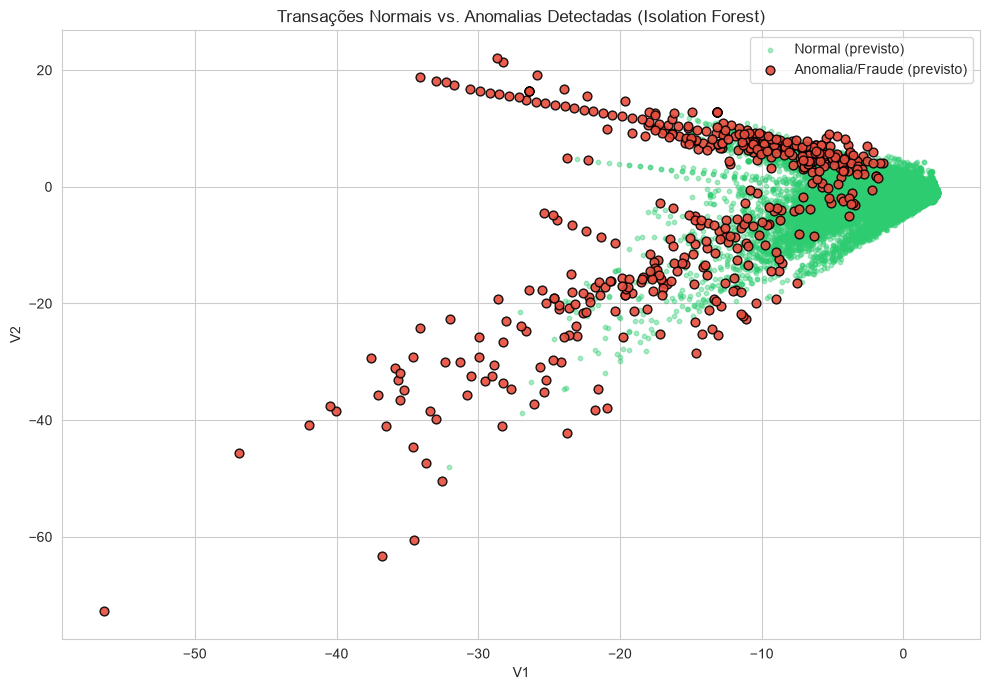

In [16]:
plt.figure(figsize=(10, 7))

# Transações normais detectadas
normal_mask = df["predicao"] == 0
plt.scatter(df.loc[normal_mask, "V1"], df.loc[normal_mask, "V2"],
            c="#2ecc71", label="Normal (previsto)", alpha=0.4, s=10)

# Anomalias detectadas
fraude_mask = df["predicao"] == 1
plt.scatter(df.loc[fraude_mask, "V1"], df.loc[fraude_mask, "V2"],
            c="#e74c3c", label="Anomalia/Fraude (previsto)", alpha=0.9, s=40, edgecolors="black")

plt.xlabel("V1")
plt.ylabel("V2")
plt.title("Transações Normais vs. Anomalias Detectadas (Isolation Forest)")
plt.legend()
plt.tight_layout()
plt.savefig("images/anomalias_scatter.png", dpi=120)
plt.show()

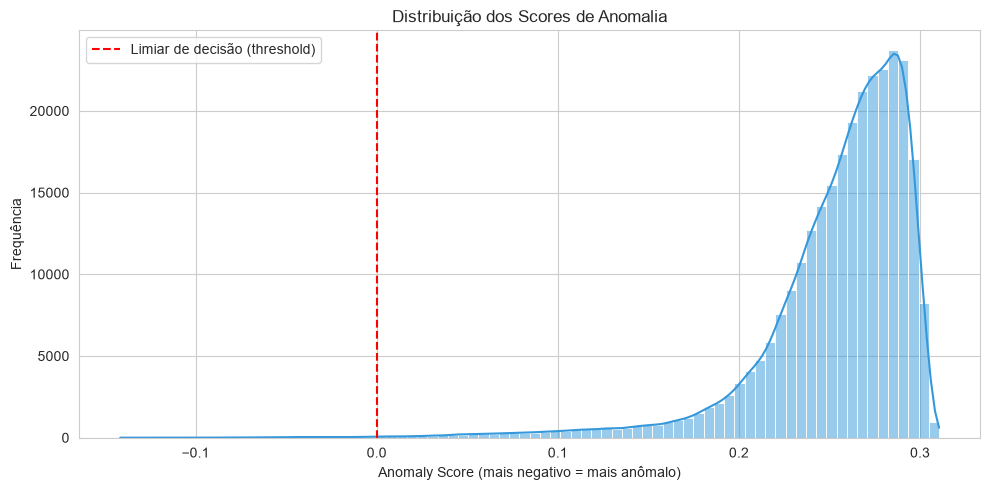

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(df["anomaly_score"], bins=80, kde=True, color="#3498db")
plt.axvline(0, color="red", linestyle="--", label="Limiar de decisão (threshold)")
plt.title("Distribuição dos Scores de Anomalia")
plt.xlabel("Anomaly Score (mais negativo = mais anômalo)")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.savefig("images/distribuicao_scores.png", dpi=120)
plt.show()

## 6. Conclusão

O **Isolation Forest** se mostrou eficaz para identificar transações anômalas sem a necessidade de rótulos durante o treinamento (abordagem não supervisionada) — o que é especialmente útil em cenários reais, onde fraudes novas (ainda não catalogadas) podem surgir.

**Principais aprendizados:**
- Dados extremamente desbalanceados exigem métricas como **Recall** e **Precision**, nunca acurácia simples.
- Padronizar variáveis com escalas diferentes (`Amount`) é essencial antes de aplicar algoritmos baseados em distância/isolamento.
- Existe um trade-off entre Recall e Precision: aumentar a sensibilidade do modelo (capturar mais fraudes) tende a aumentar também os falsos positivos.

**Próximos passos possíveis:**
- Testar `Local Outlier Factor (LOF)` e comparar resultados
- Testar abordagem supervisionada (Random Forest / XGBoost) com `SMOTE` para balanceamento
- Ajustar o parâmetro `contamination` e analisar o impacto no Recall/Precision
- Implementar validação cruzada para maior robustez